In [ ]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")


In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/job_postings_raw.csv")

print("shape:", df.shape)
print("columns:", list(df.columns)[:10], "... total:", len(df.columns))

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("after drop shape:", df.shape)
print("has Unnamed 0:", "Unnamed: 0" in df.columns)

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
print(missing.head(15))

In [ ]:
print(df["location"].value_counts().head(20))

In [ ]:
df["location"] = df["location"].astype(str).str.strip()

df["location"] = df["location"].replace({
"Anywhere": "Anywhere",
"United States": "United States"
})

print(df["location"].value_counts().head(10))

In [ ]:
bg = df[df["location"].str.contains("bulgaria|sofia|plovdiv|varna|burgas|ruse", case=False, na=False)]
print("BG rows:", bg.shape[0])
bg["location"].value_counts().head(20)

In [16]:
skills = ["python","sql","excel","power bi","tableau","pandas","spark","aws","azure","gcp"]

for s in skills:
df["skill_" + s.replace(" ", "_")] = df["description"].astype(str).str.lower().str.contains(s, na=False).astype(int)

skill_cols = [c for c in df.columns if c.startswith("skill_")]

top = (df[skill_cols].mean().sort_values(ascending=False) * 100).round(1)
print(top)

IndentationError: expected an indented block after 'for' statement on line 3 (841340815.py, line 4)

In [17]:

skills = ["python","sql","excel","power bi","tableau","pandas","spark","aws","azure","gcp"]

for s in skills:
    df["skill_" + s.replace(" ", "_")] = df["description"].astype(str).str.lower().str.contains(s, na=False).astype(int)

skill_cols = [c for c in df.columns if c.startswith("skill_")]

top = (df[skill_cols].mean().sort_values(ascending=False) * 100).round(1)
print(top)  

skill_excel       54.1
skill_sql         52.2
skill_python      31.4
skill_tableau     28.1
skill_power_bi    19.7
skill_aws         13.7
skill_azure        6.5
skill_spark        6.1
skill_gcp          2.2
skill_pandas       1.7
dtype: float64


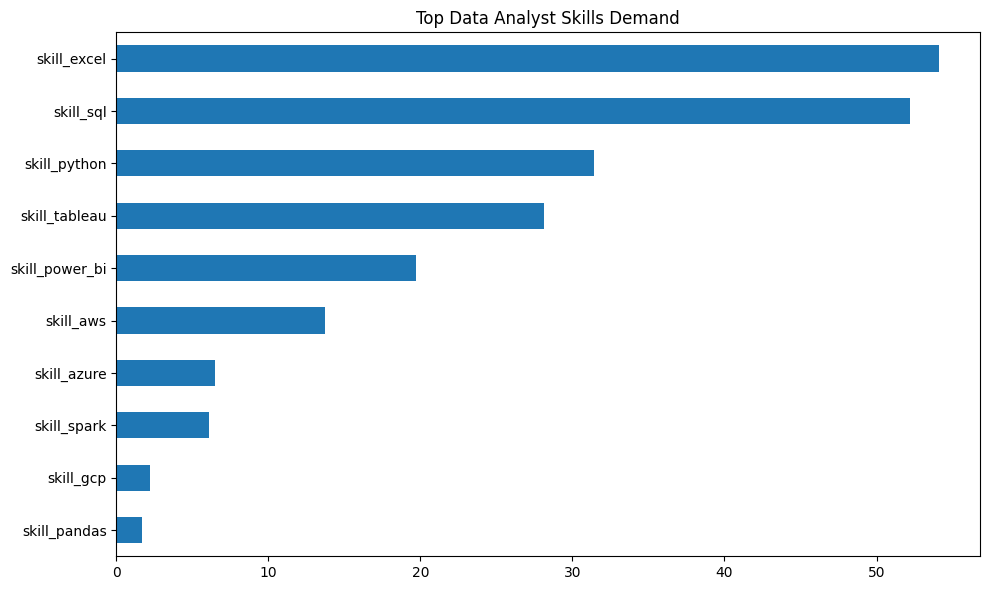

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
top.sort_values().plot(kind="barh")
plt.title("Top Data Analyst Skills Demand")
plt.tight_layout()

plt.savefig("../reports/figures/top_skills.png")

plt.show()


Top skills analysis:

Excel and SQL dominate the market with over 50 percent demand.
Python appears in about one third of job postings.
Business Intelligence tools Tableau and Power BI show strong demand.
Cloud skills AWS Azure and GCP appear increasingly often.

This indicates that core analytics skills SQL Excel plus Python remain essential while visualization and cloud skills provide competitive advantage.

In [19]:
df["salary_avg"].describe()


count     10088.000000
mean      42100.231239
std       55893.993519
min           7.250000
25%          31.500000
50%          60.000000
75%       92500.000000
max      550000.000000
Name: salary_avg, dtype: float64

In [20]:
df["salary_rate"].value_counts(dropna=False).head(10)


salary_rate
NaN        51865
an hour     5900
a year      4069
a month      119
Name: count, dtype: int64

In [21]:
hourly = df[df["salary_rate"] == "an hour"].copy()
hourly = hourly[(hourly["salary_avg"] >= 10) & (hourly["salary_avg"] <= 250)]

print("hourly rows:", hourly.shape[0])
print(hourly["salary_avg"].describe())


hourly rows: 5884
count    5884.000000
mean       40.488583
std        21.534749
min        10.000000
25%        23.265000
50%        33.500000
75%        55.000000
max       225.000000
Name: salary_avg, dtype: float64


In [22]:
yearly = df[df["salary_rate"] == "a year"].copy()
yearly = yearly[(yearly["salary_avg"] >= 20000) & (yearly["salary_avg"] <= 400000)]

print("yearly rows:", yearly.shape[0])
print(yearly["salary_avg"].describe())


yearly rows: 4065
count      4065.000000
mean     103741.965544
std       33991.477193
min       29289.840000
25%       80000.000000
50%       96500.000000
75%      120000.000000
max      300000.000000
Name: salary_avg, dtype: float64


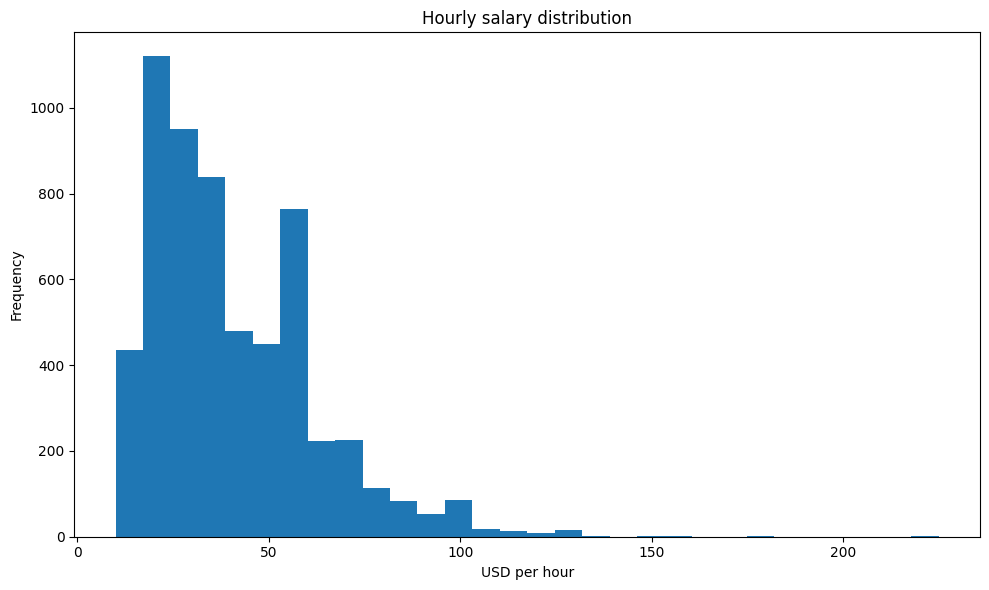

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
hourly["salary_avg"].plot(kind="hist", bins=30)
plt.title("Hourly salary distribution")
plt.xlabel("USD per hour")
plt.tight_layout()
plt.savefig("../reports/figures/salary_hourly_hist.png")
plt.show()


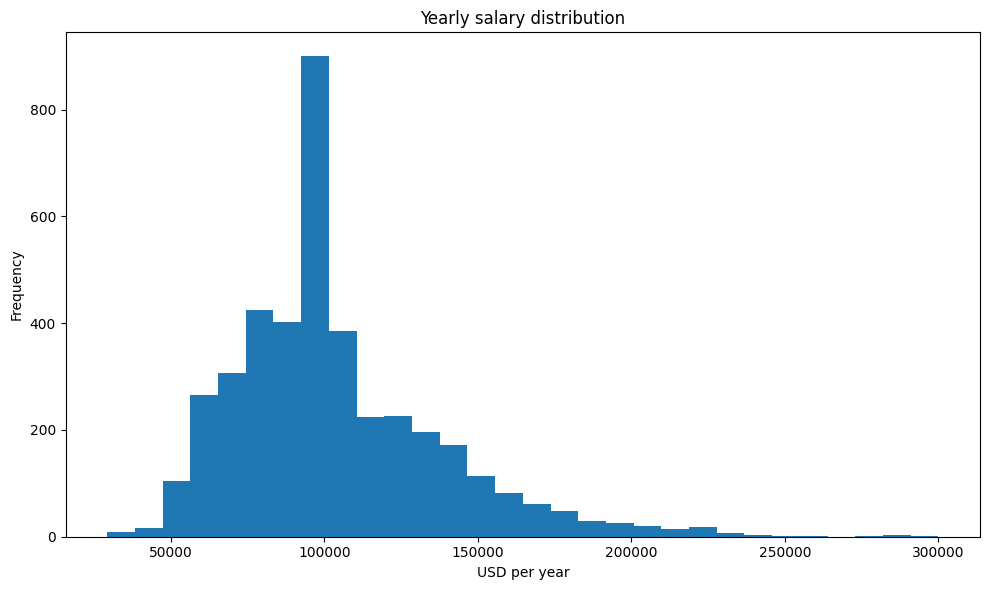

In [24]:
plt.figure(figsize=(10,6))
yearly["salary_avg"].plot(kind="hist", bins=30)
plt.title("Yearly salary distribution")
plt.xlabel("USD per year")
plt.tight_layout()
plt.savefig("../reports/figures/salary_yearly_hist.png")
plt.show()


In [25]:
df.to_csv("../data/processed/jobs_clean.csv", index=False)
